# Frequency Check

In [ ]:
import pandas as pd
import numpy as np

FILE_PATH = "../Datasets/Raw_Data/Unlabeled_Data_With_GPS/Europe/Germany/Phone 9/Old_Town_Nuremberg_Nuremberg_AccelerometerData.csv"

df = pd.read_csv(FILE_PATH)

# Inter-sample intervals in seconds (attr_time is ms)
dt = df["timestamp"].diff().dropna() / 1000.0
dt = dt[dt > 0]  # drop zero/negative gaps (duplicates or resets)

freq_hz = 1.0 / dt

# Round to nearest integer Hz to find the dominant frequency
dominant_hz = int(freq_hz.round().mode()[0])

print(f"{'Samples':<20}: {len(df)}")
print(f"{'Duration':<20}: {(df['timestamp'].iloc[-1] - df['timestamp'].iloc[0]) / 1000:.2f} s")
print()
print(f"{'Dominant freq':<20}: {dominant_hz} Hz")
print(f"{'Mean freq':<20}: {freq_hz.mean():.2f} Hz")
print(f"{'Median freq':<20}: {freq_hz.median():.2f} Hz")
print(f"{'Std freq':<20}: {freq_hz.std():.2f} Hz")
print(f"{'Min / Max freq':<20}: {freq_hz.min():.2f} / {freq_hz.max():.2f} Hz")


Samples             : 146961
Duration            : 147.19 s

Dominant freq       : 500 Hz
Mean freq           : 577.74 Hz
Median freq         : 500.00 Hz
Std freq            : 207.44 Hz
Min / Max freq      : 250.00 / 1000.00 Hz


# Data Check

In [43]:
def remove_stalled_regions(
    df: pd.DataFrame,
    sampling_rate: int = 50,
    window_seconds: float = 120.0,
) -> pd.DataFrame:
    df = df.copy().reset_index(drop=True)

    magnitude = np.sqrt(df['attr_x']**2 + df['attr_y']**2 + df['attr_z']**2)
    diff = magnitude.diff().abs().fillna(0)

    global_mean_diff = diff.mean()

    window_samples = int(window_seconds * sampling_rate)
    window_mean_diff = diff.rolling(window=window_samples, center=True, min_periods=1).mean()

    remove_mask = (window_mean_diff < global_mean_diff).values  # numpy array, index-safe

    clean_df = df[~remove_mask].reset_index(drop=True)
    print(f"Global mean diff: {global_mean_diff:.4f} | Removed: {remove_mask.sum()} / {len(df)} → {len(clean_df)} remaining")
    return clean_df


In [53]:
import pandas as pd
import matplotlib.pyplot as plt

FILE_PATH = "../Datasets/Raw_Data/Unlabeled_Data_With_GPS/Europe/Germany/Phone 9/Old_Town_Nuremberg_Nuremberg_AccelerometerData.csv"

df = pd.read_csv(FILE_PATH)
df = remove_stalled_regions(df, sampling_rate=50, window_seconds=20.0)

t = (df["attr_time"] - df["attr_time"].iloc[0]) / 1000.0

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle("Nazi Party Rally Ground Nuremberg — Accelerometer Data", fontsize=14)

for col, color in zip(["attr_x", "attr_y", "attr_z"], ["tab:blue", "tab:orange", "tab:green"]):
    ax.plot(t, df[col], color=color, linewidth=0.5, label=col)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Acceleration (m/s²)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Samples : {len(df)}")
print(f"Duration: {t.iloc[-1]:.2f} s")


TypeError: remove_stalled_regions() got an unexpected keyword argument 'window_seconds'

In [58]:
# data processing pipeline

import numpy as np
from scipy.signal import butter, sosfiltfilt
from scipy import stats
from scipy.ndimage import label

# Trimping function to remove start/end artifacts
def trim_signal(data, trim_percent=0.1):
    """Trim a percentage of samples from the start and end of the signal."""
    trim_count = int(len(data) * trim_percent)

    return data[trim_count:-trim_count].reset_index(drop=True)

# Butterworth filter design using SOS for stability
def _design_butterworth_filter(cutoff, fs, btype, order=4):
    """Design a Butterworth filter and return SOS coefficients."""
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist

    if normal_cutoff >= 1.0:
        raise ValueError(
            f"lowpass_cutoff ({cutoff} Hz) must be < Nyquist ({nyquist} Hz) for fs={fs} Hz."
        )

    return butter(order, normal_cutoff, btype=btype, output='sos')


def run_butterworth(data, fs = 50, highpass_cutoff=0.3, lowpass_cutoff=15, order=4):
    """
    Apply bandpass filtering (highpass + lowpass) to X, Y, Z accelerometer columns.
    Uses SOS format for numerical stability.
    """
    # Design filters once, reuse across axes
    sos_high = _design_butterworth_filter(highpass_cutoff, fs, btype='high', order=order)
    sos_low  = _design_butterworth_filter(lowpass_cutoff,  fs, btype='low',  order=order)

    cols = ['attr_x', 'attr_y', 'attr_z']
    raw = data[cols].values  # (N, 3) — process all axes at once

    filtered = sosfiltfilt(sos_high, raw, axis=0)
    filtered = sosfiltfilt(sos_low,  filtered, axis=0)

    data_filtered = data.copy()
    data_filtered[cols] = filtered

    return data_filtered


# Hampel filter implementation
def _hampel_filter_vectorized(signal: np.ndarray, window_size: int = 10, n_sigmas: float = 3) -> np.ndarray:
    """
    Fully vectorized Hampel filter — significantly faster for large arrays.
    Uses stride tricks to build a sliding window matrix in one operation.
    """
    if not isinstance(signal, np.ndarray):
        signal = np.asarray(signal, dtype=float)

    L = len(signal)
    new_signal = signal.copy()

    # Build sliding window view using stride tricks (zero-copy)
    win_full = 2 * window_size + 1
    shape = (L - 2 * window_size, win_full)
    strides = (signal.strides[0], signal.strides[0])
    windows = np.lib.stride_tricks.as_strided(signal, shape=shape, strides=strides)

    medians = np.median(windows, axis=1)
    mads = stats.median_abs_deviation(windows, axis=1)

    threshold = n_sigmas * np.maximum(mads, 1e-10)
    center_vals = signal[window_size : L - window_size]
    outlier_mask = np.abs(center_vals - medians) > threshold 


    new_signal[window_size : L - window_size][outlier_mask] = medians[outlier_mask]

    return new_signal


def run_hampel(data, vectorized: bool = True):
    """
    Apply Hampel filter to attr_x, attr_y, attr_z columns.

    Args:
        data: DataFrame with columns attr_x, attr_y, attr_z
        vectorized: Use fast vectorized implementation (default: True)
    """

    required_cols = ['attr_x', 'attr_y', 'attr_z']
    missing = [c for c in required_cols if c not in data.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    data_filtered = data.copy()

    # Process all columns in a single loop instead of repeating code
    for col in required_cols:
        data_filtered[col] = _hampel_filter_vectorized(data[col].values, window_size=10, n_sigmas=3)

    return data_filtered

# Remove stalled (flat/motionless) regions from accelerometer data
def remove_stalled_regions(
    df: pd.DataFrame,
    sampling_rate: int = 50,
    change_threshold: float = 1e-5,
    min_stall_seconds: float = 2.0
) -> pd.DataFrame:
    """
    Remove stalled (flat/motionless) regions from accelerometer data.

    Args:
        df: DataFrame with columns attr_x, attr_y, attr_z
        sampling_rate: Samples per second
        change_threshold: Max diff magnitude to consider a point "flat"
        min_stall_seconds: Minimum duration (seconds) to classify as a stall

    Returns:
        DataFrame with stalled regions removed and index reset
    """
    required_cols = ['attr_x', 'attr_y', 'attr_z']
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    if sampling_rate <= 0:
        raise ValueError("sampling_rate must be positive")
    if min_stall_seconds <= 0:
        raise ValueError("min_stall_seconds must be positive")

    df = df.copy()

    # Compute magnitude
    magnitude = np.sqrt(df['attr_x']**2 + df['attr_y']**2 + df['attr_z']**2)

    # Use np.diff directly (faster than pandas .diff())
    diff = np.empty(len(magnitude))
    diff[0] = 0.0
    diff[1:] = np.abs(np.diff(magnitude))

    # Identify flat points
    flat_mask = diff < change_threshold

    # Convert duration to samples
    min_samples = int(min_stall_seconds * sampling_rate)

    # instead of Python for-loop over every sample
    labeled_array, num_features = label(flat_mask)

    remove_mask = np.zeros(len(df), dtype=bool)

    for region_id in range(1, num_features + 1):
        region_indices = np.where(labeled_array == region_id)[0]
        if len(region_indices) >= min_samples:
            remove_mask[region_indices] = True

    return df.loc[~remove_mask].reset_index(drop=True)

Found 25 accelerometer files


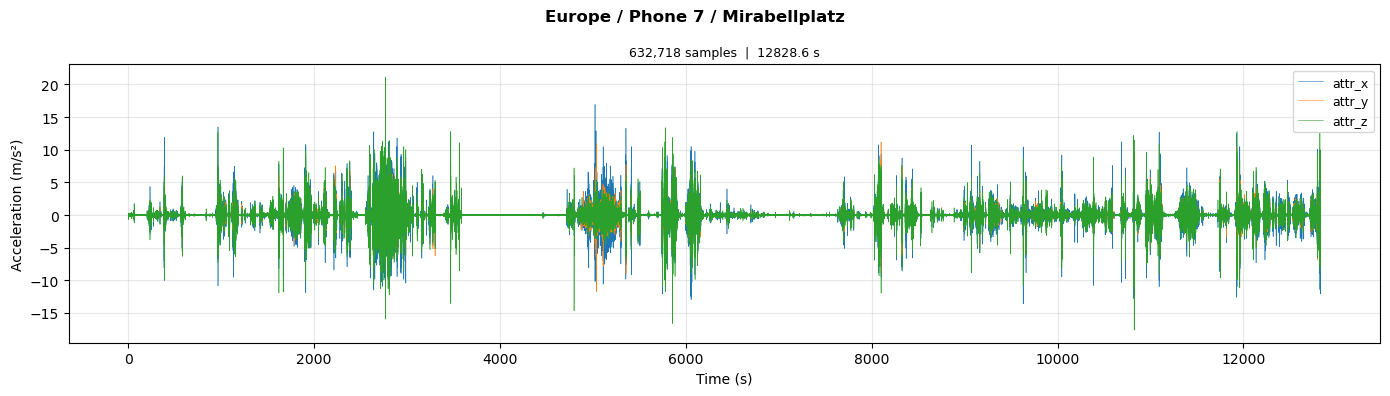

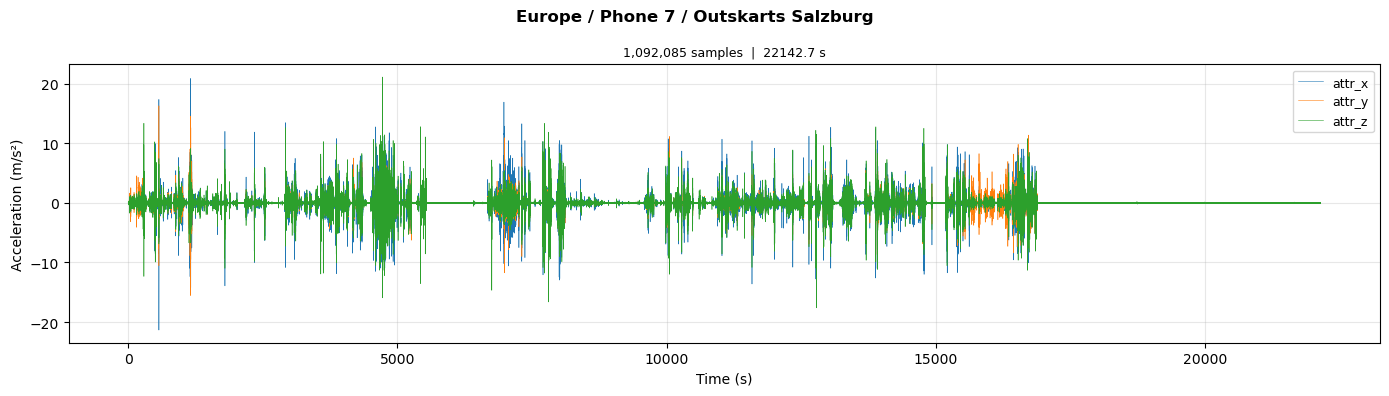

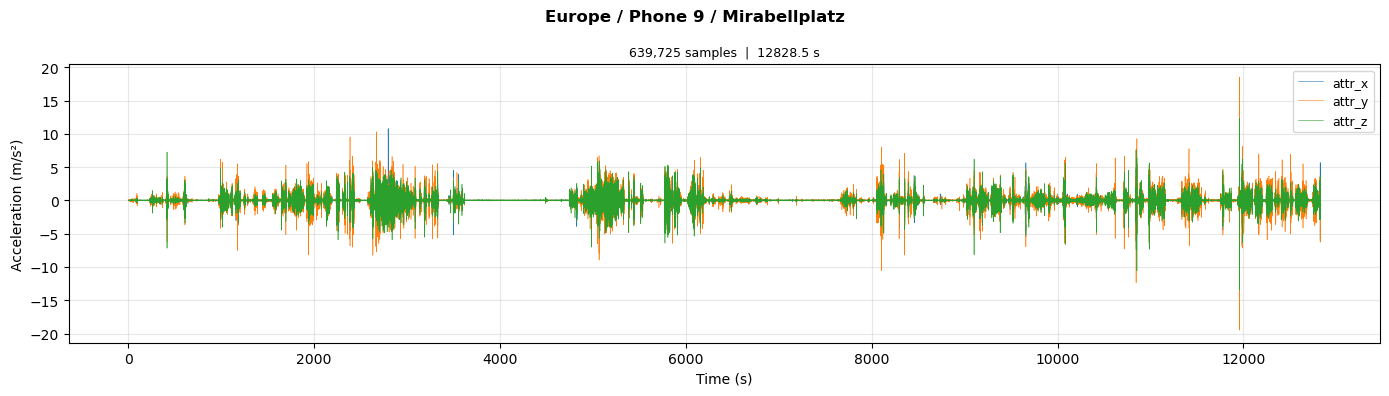

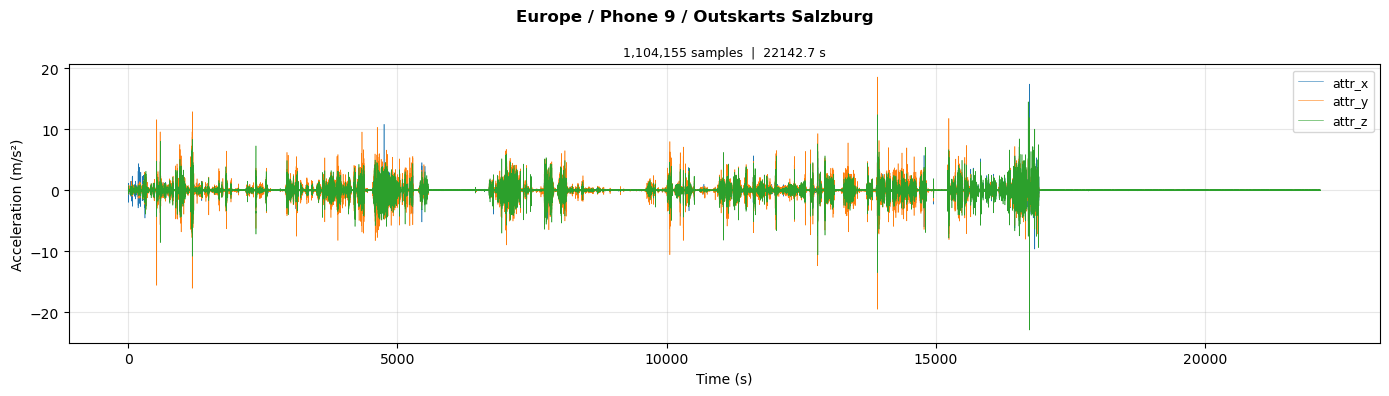

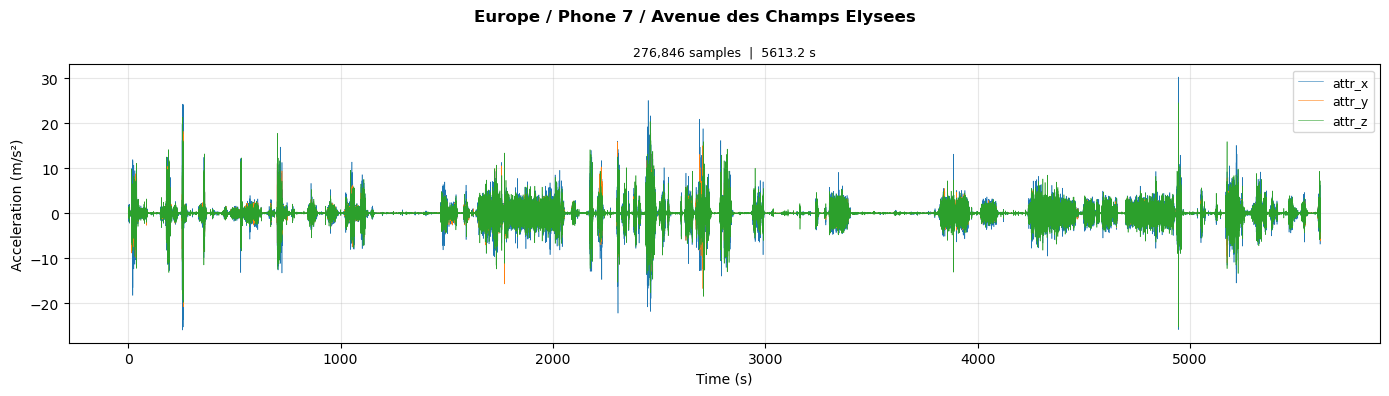

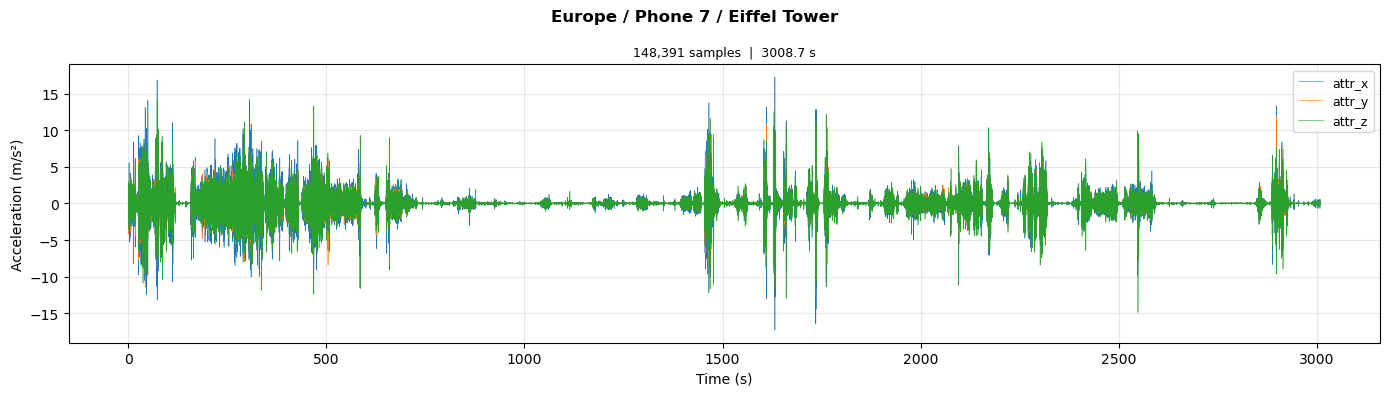

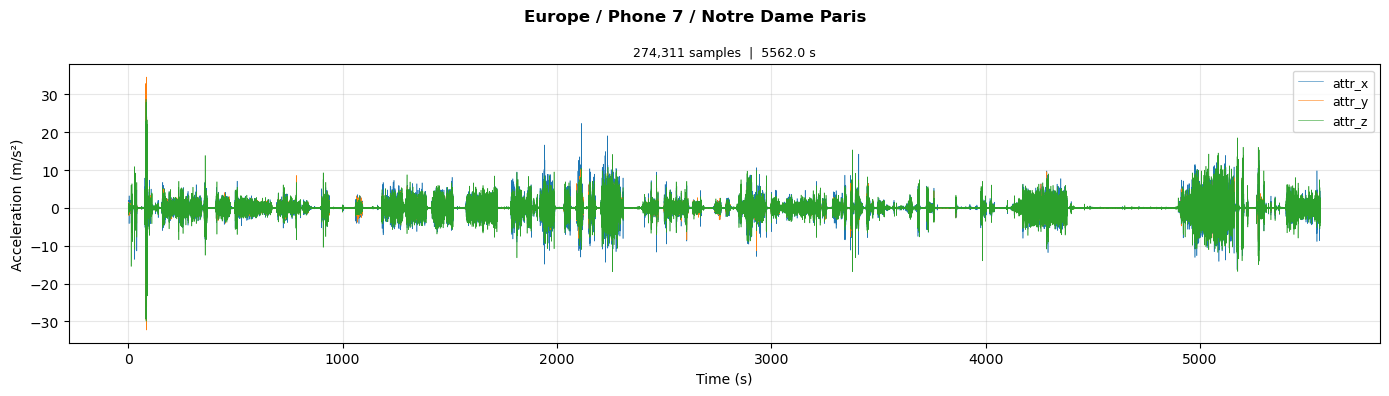

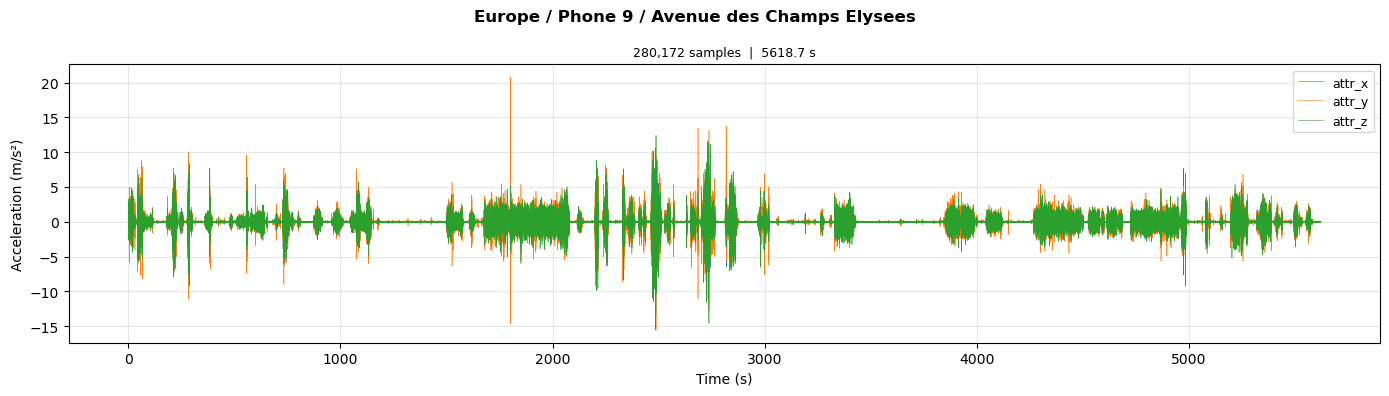

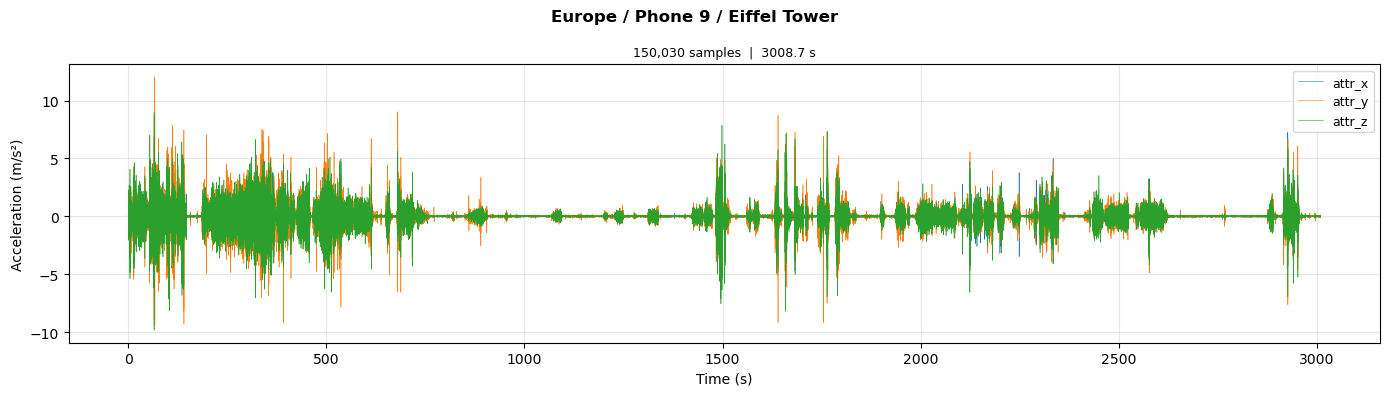

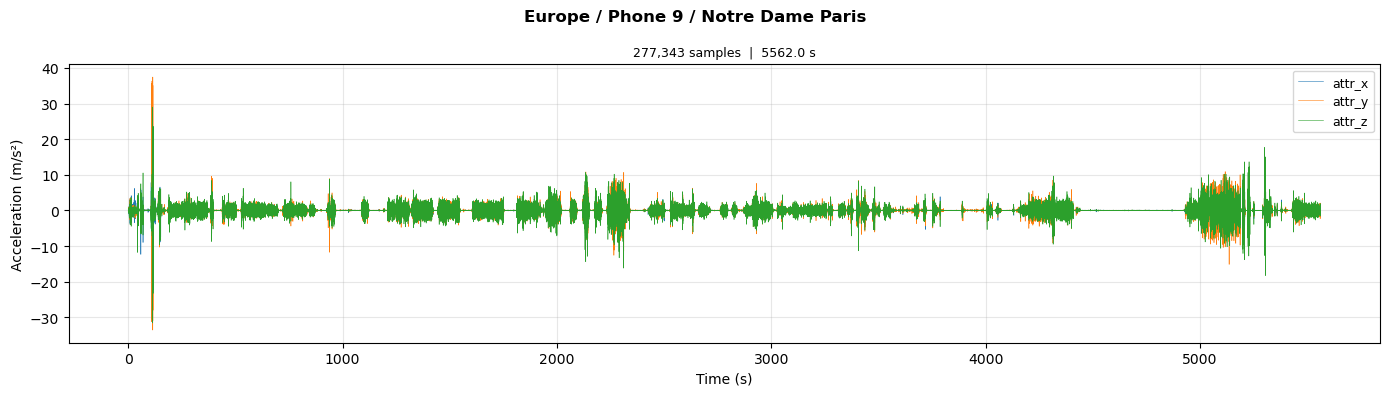

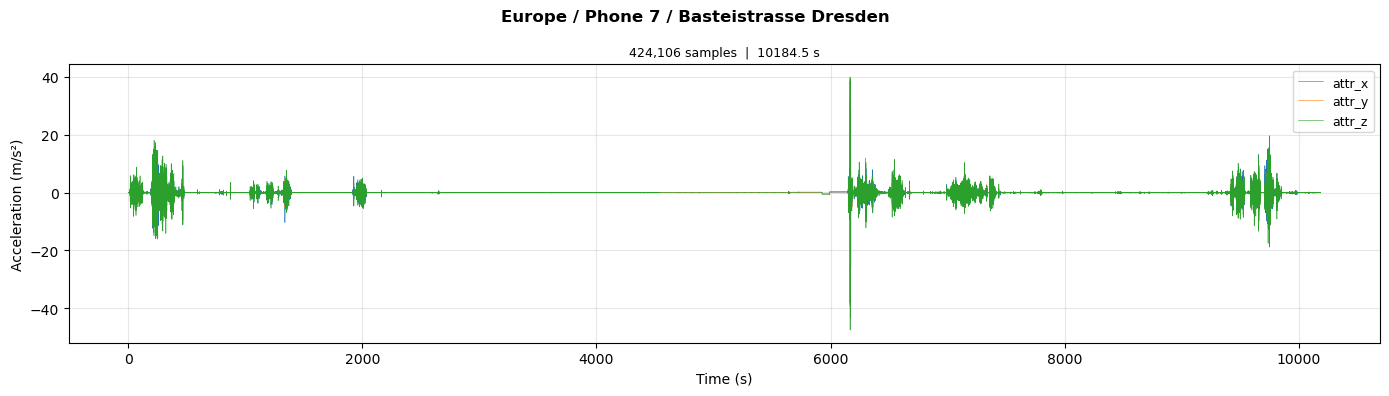

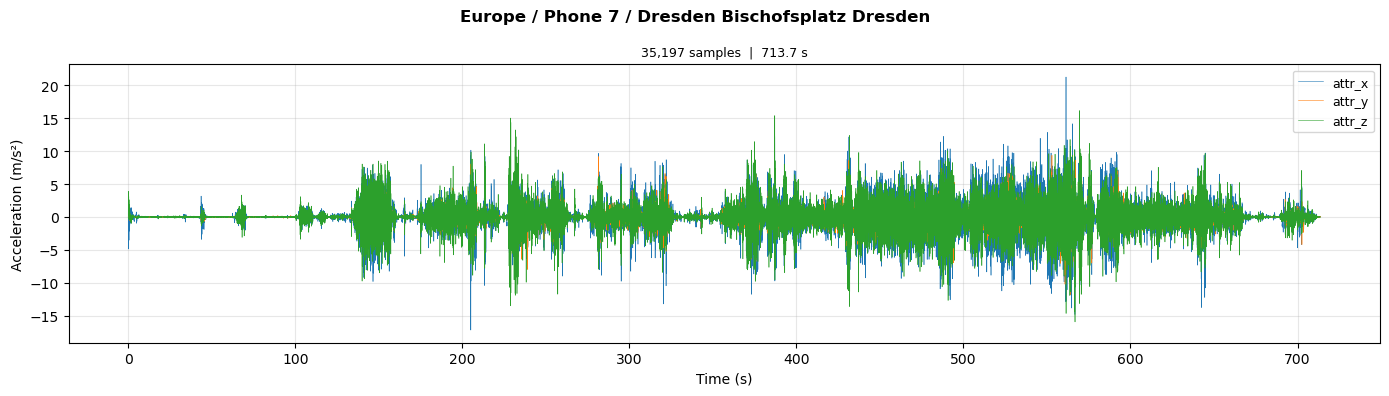

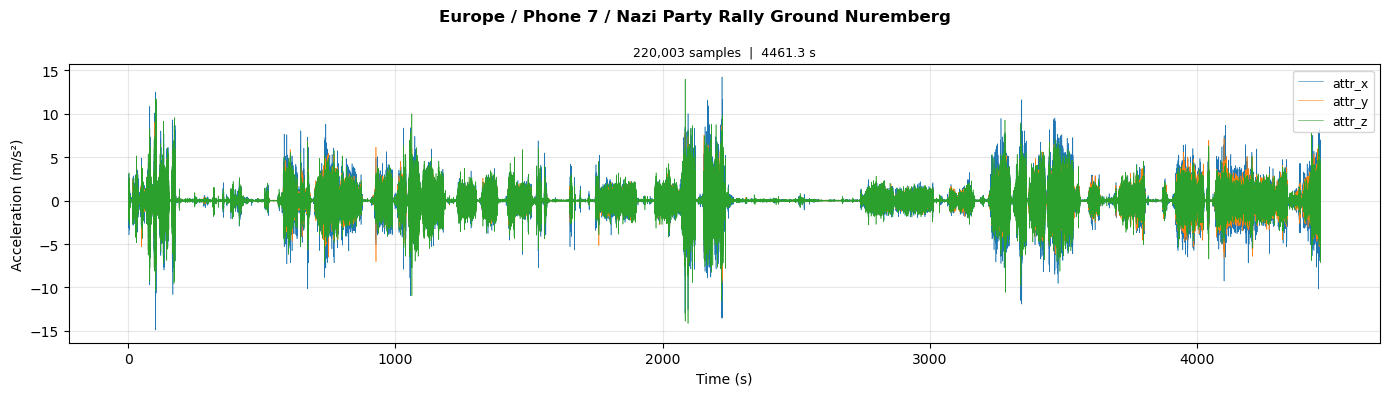

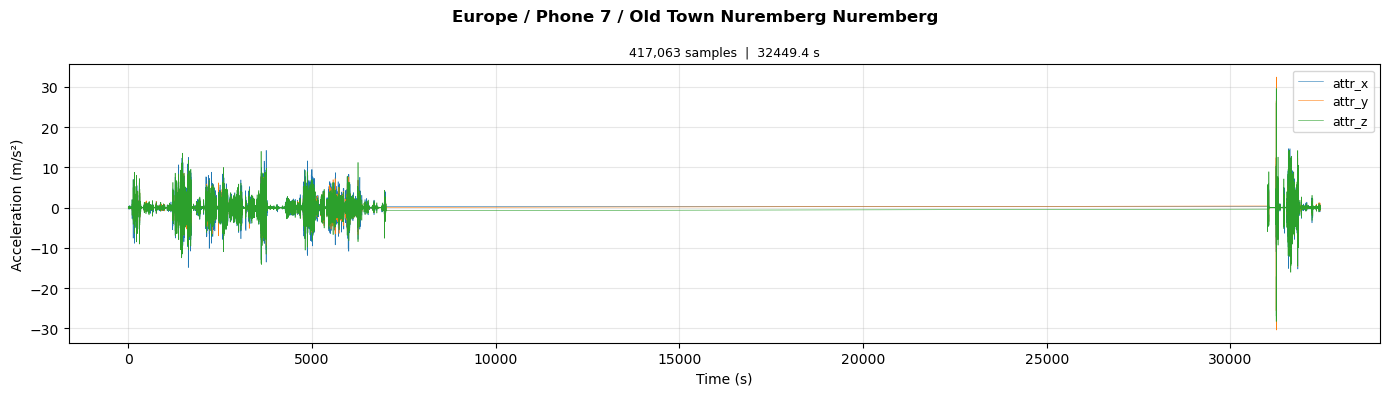

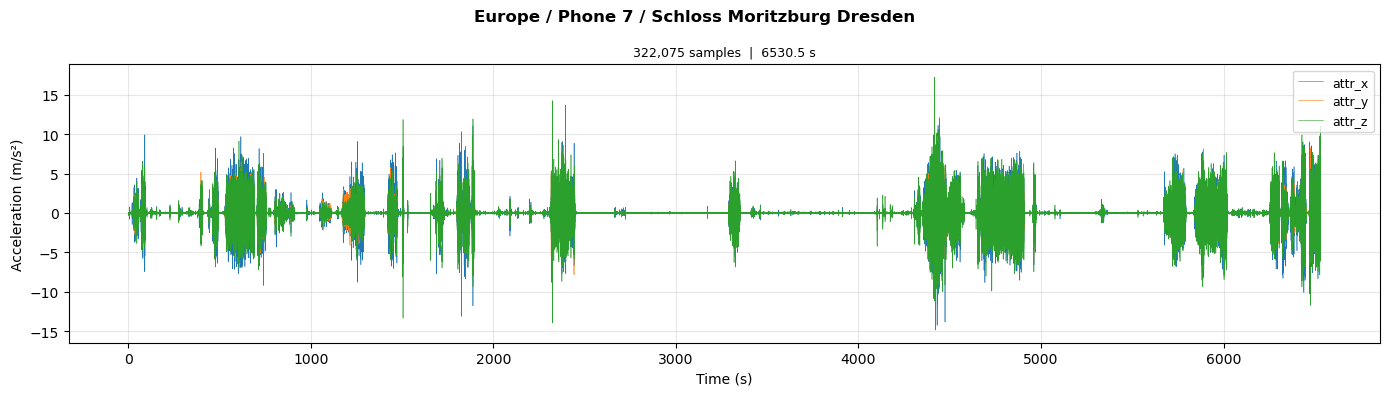

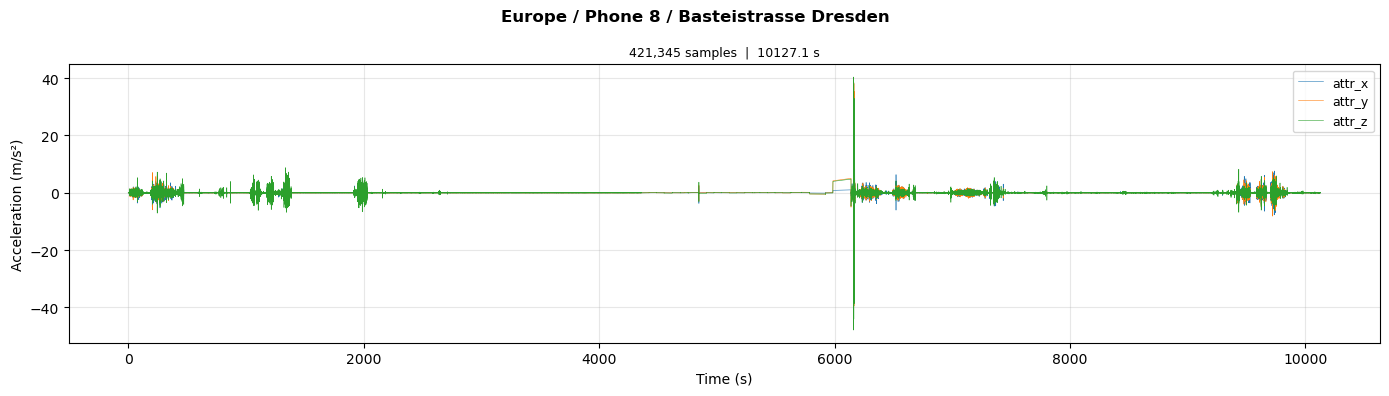

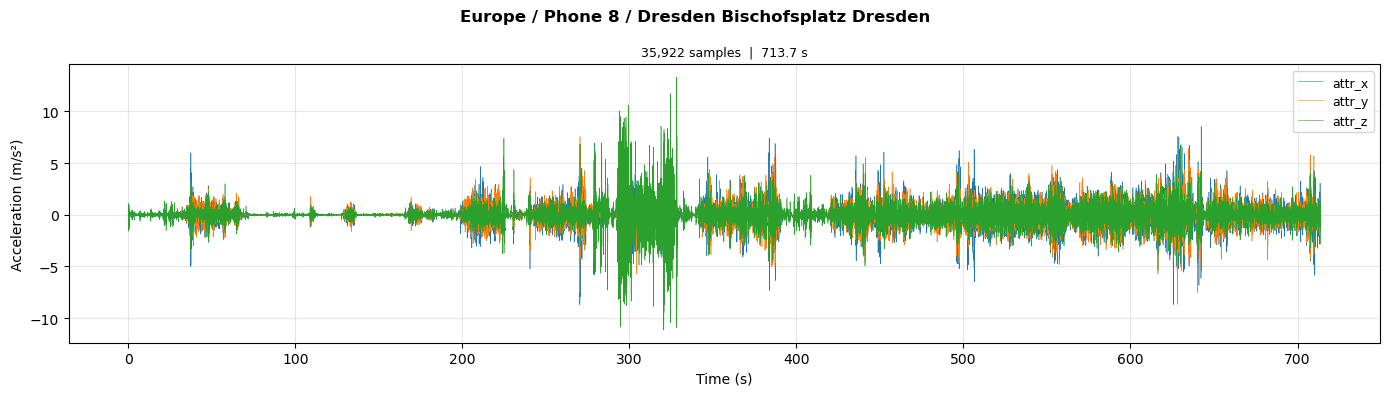

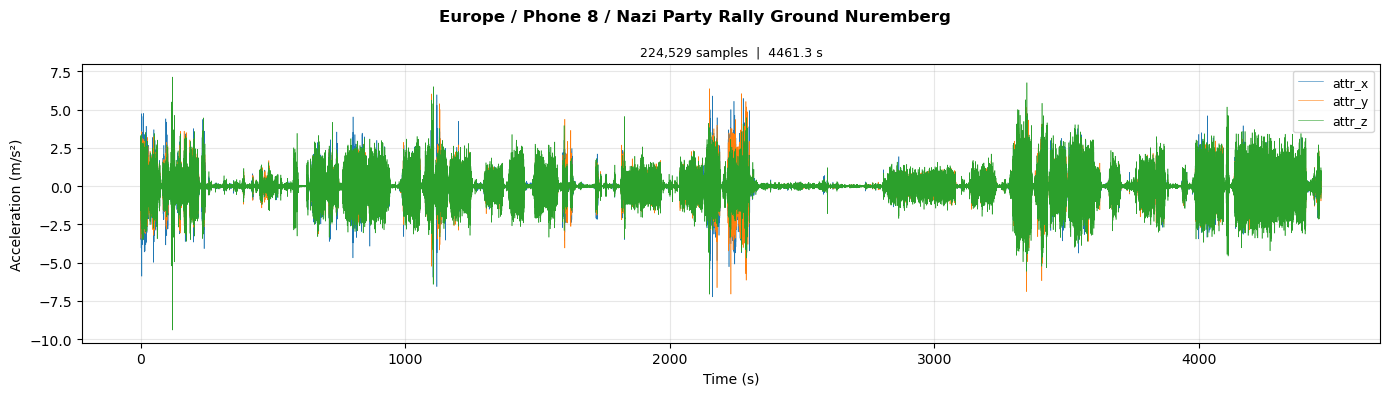

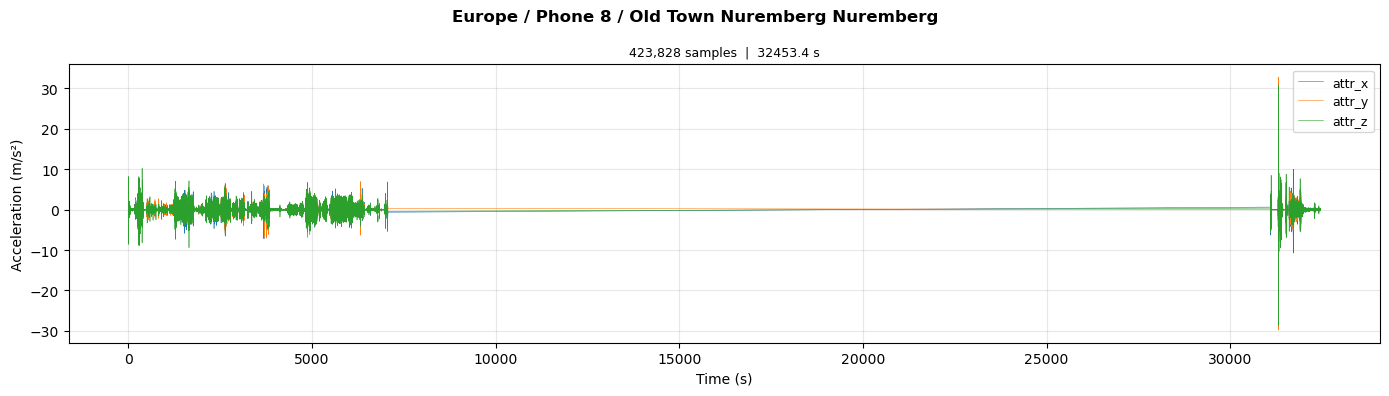

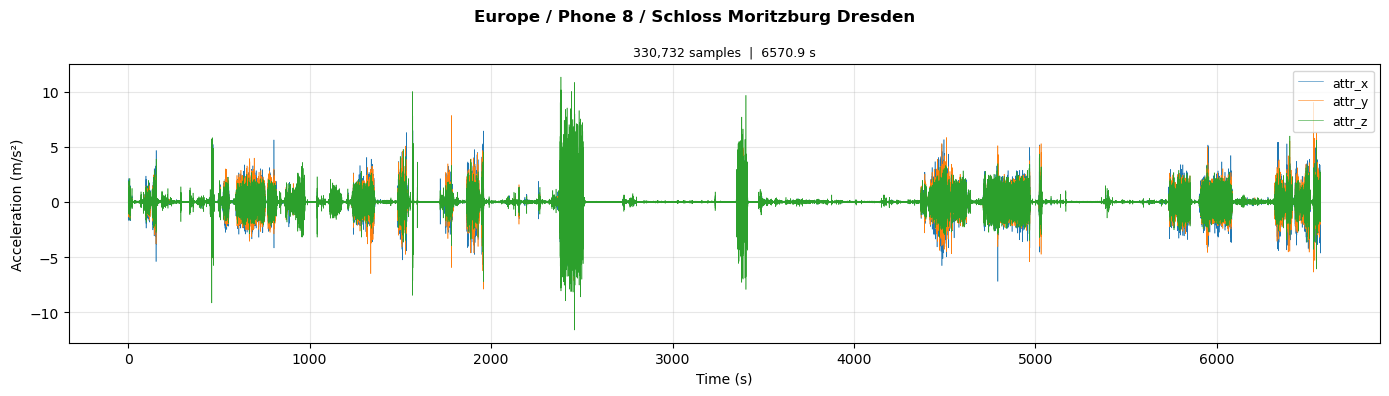

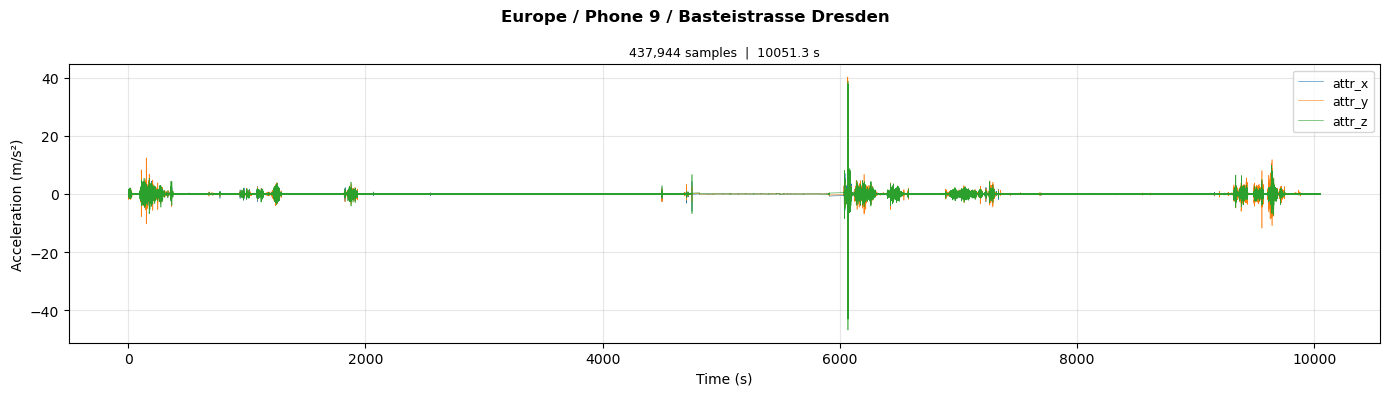

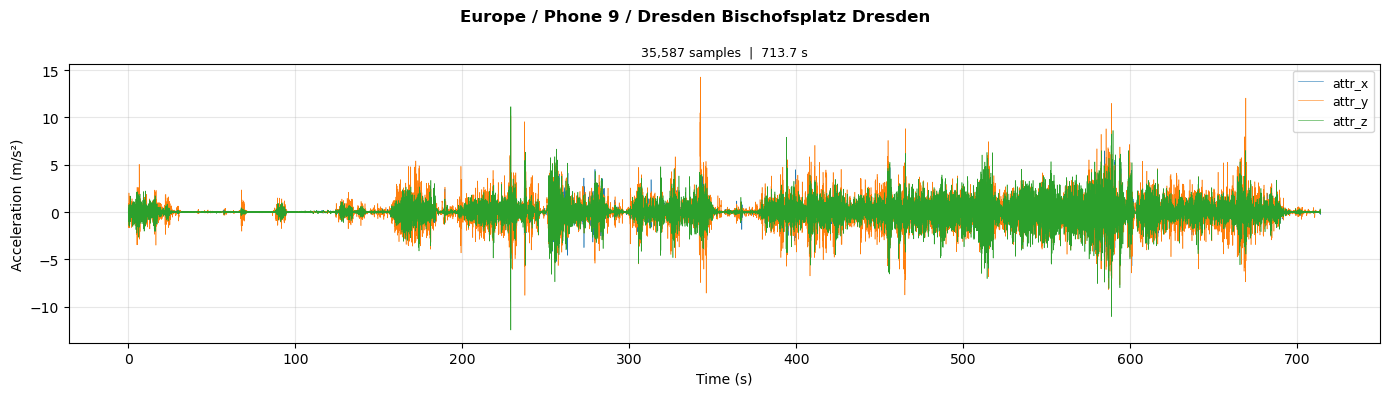

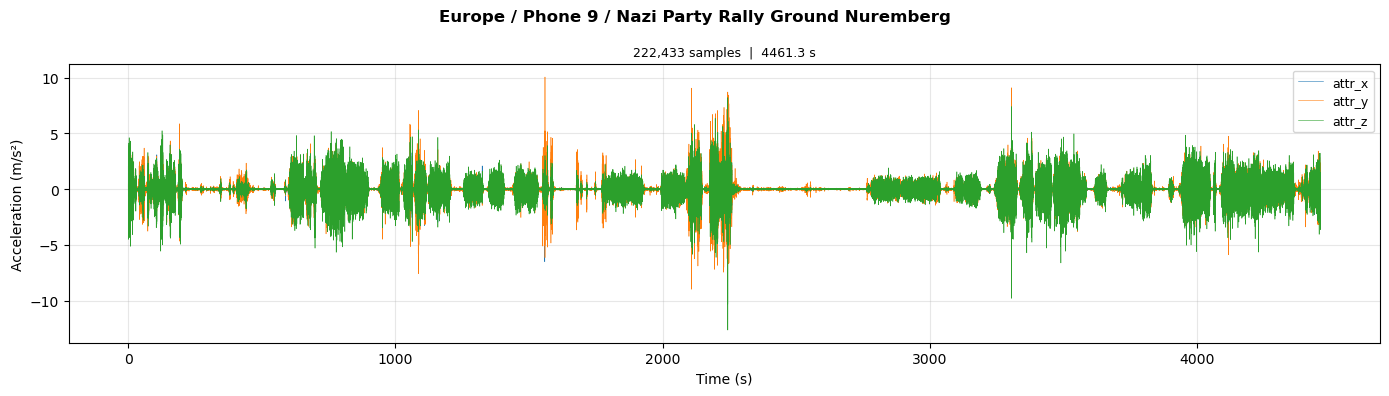

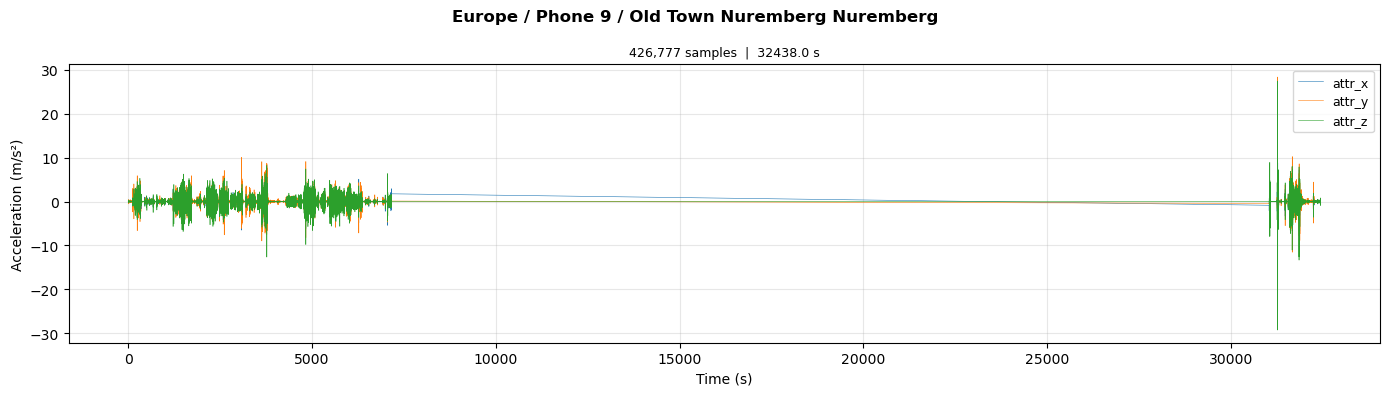

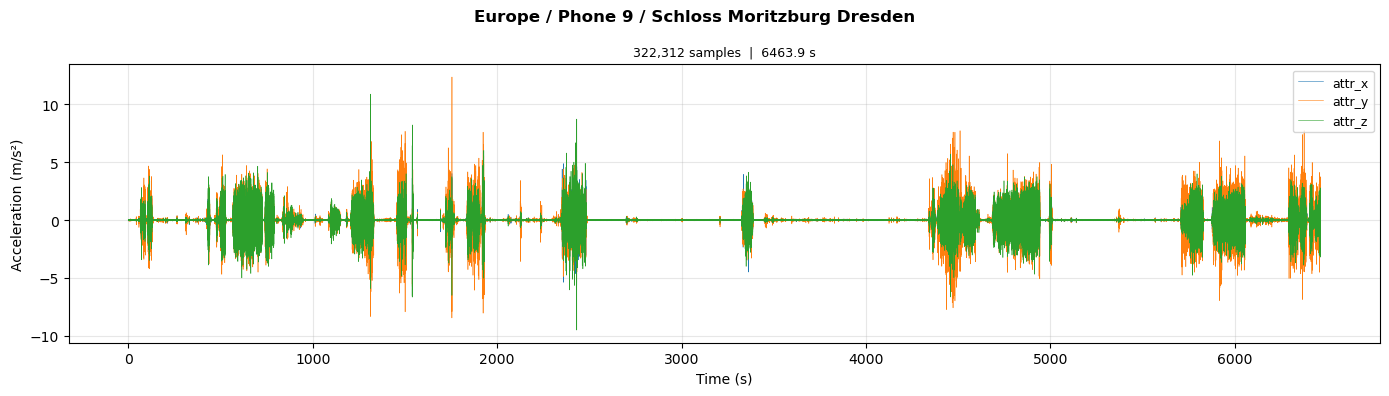

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

BASE_DIR = Path("../Datasets/Raw_Data/Unlabeled_Data_With_GPS")
accel_files = sorted(BASE_DIR.rglob("*AccelerometerData*.csv"))

print(f"Found {len(accel_files)} accelerometer files")

for f in accel_files:
    parts = f.parts
    country = parts[-4] if len(parts) >= 4 else "?"
    phone   = parts[-2] if len(parts) >= 2 else "?"
    location = f.stem.replace("_AccelerometerData", "").replace("_", " ")
    title = f"{country} / {phone} / {location}"

    try:
        df = pd.read_csv(f)

        df = trim_signal(df, trim_percent=0.05)
        df = run_butterworth(df, fs=50, highpass_cutoff=0.3, lowpass_cutoff=15, order=4)
        df = run_hampel(df, vectorized=True)
        df = remove_stalled_regions(df)

        time_col = "attr_time" if "attr_time" in df.columns else df.columns[1]
        t = (df[time_col] - df[time_col].iloc[0]) / 1000.0

        fig, ax = plt.subplots(figsize=(14, 4))
        fig.suptitle(title, fontsize=12, fontweight="bold")

        colors = {"attr_x": "tab:blue", "attr_y": "tab:orange", "attr_z": "tab:green"}
        for col, color in colors.items():
            if col in df.columns:
                ax.plot(t, df[col], color=color, linewidth=0.4, label=col)

        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Acceleration (m/s²)")
        ax.legend(loc="upper right", fontsize=9)
        ax.grid(True, alpha=0.3)
        duration = t.iloc[-1]
        ax.set_title(f"{len(df):,} samples  |  {duration:.1f} s", fontsize=9)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"  ERROR: {title} — {e}")
